In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)
from sklearn.feature_selection import RFE, mutual_info_classif
import joblib

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('All libraries imported successfully!')


All libraries imported successfully!


In [4]:
# ── PATH FIX ──────────────────────────────────────────────────────────────────
# Option A (recommended): put the CSV next to this notebook, path = just the filename
DATASET_PATH = 'ball_by_ball_it20.csv'

# Option B: absolute path – uncomment and edit if needed
# DATASET_PATH = r'C:\Users\YourName\Downloads\ball_by_ball_it20.csv'
# ──────────────────────────────────────────────────────────────────────────────

df_raw = pd.read_csv(DATASET_PATH, index_col=0)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Dataset loaded: 425,119 rows × 34 columns


,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,Non Striker,...,Winner,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball
0,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,1,1,1,BA King,KR Mayers,...,South Africa,1,1,0,1,0,NaN,NaN,1,1
1,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,1,1,2,KR Mayers,BA King,...,South Africa,1,1,1,1,1,NaN,NaN,1,1
2,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,1,1,3,BA King,KR Mayers,...,South Africa,1,0,1,0,1,1.0,2.0,0,1


In [5]:
print('=== Schema ===')
print(df_raw.dtypes)
print(f'\nShape: {df_raw.shape}')

=== Schema ===
Match ID                     int64
Date                        object
Venue                       object
Bat First                   object
Bat Second                  object
Innings                      int64
Over                         int64
Ball                         int64
Batter                      object
Non Striker                 object
Bowler                      object
Batter Runs                  int64
Extra Runs                   int64
Runs From Ball               int64
Ball Rebowled                int64
Extra Type                  object
Wicket                       int64
Method                      object
Player Out                  object
Innings Runs                 int64
Innings Wickets              int64
Target Score                 int64
Runs to Get                float64
Balls Remaining              int64
Winner                      object
Chased Successfully          int64
Total Batter Runs            int64
Total Non Striker Runs       int64
Batte

In [6]:
# Identify numerical vs categorical
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
print('Numerical columns:', num_cols)
print('\nCategorical columns:', cat_cols)

Numerical columns: ['Match ID', 'Innings', 'Over', 'Ball', 'Batter Runs', 'Extra Runs', 'Runs From Ball', 'Ball Rebowled', 'Wicket', 'Innings Runs', 'Innings Wickets', 'Target Score', 'Runs to Get', 'Balls Remaining', 'Chased Successfully', 'Total Batter Runs', 'Total Non Striker Runs', 'Batter Balls Faced', 'Non Striker Balls Faced', 'Player Out Runs', 'Player Out Balls Faced', 'Bowler Runs Conceded', 'Valid Ball']

Categorical columns: ['Date', 'Venue', 'Bat First', 'Bat Second', 'Batter', 'Non Striker', 'Bowler', 'Extra Type', 'Method', 'Player Out', 'Winner']


In [7]:
# Scope: second innings only (chasing team) – this is where win probability is meaningful
df = df_raw[df_raw['Innings'] == 2].copy()
print(f'Second innings rows: {len(df):,}')

# Target variable: Chased Successfully (1 = batting team won, 0 = lost)
print('\nTarget variable distribution:')
print(df['Chased Successfully'].value_counts())

# Class imbalance check
ratio = df['Chased Successfully'].value_counts(normalize=True)
print('\nClass ratio:\n', ratio)

Second innings rows: 200,304

Target variable distribution:
Chased Successfully
0    106518
1     93786
Name: count, dtype: int64

Class ratio:
 Chased Successfully
0    0.531782
1    0.468218
Name: proportion, dtype: float64


In [8]:
# Duplicates & basic quality
print('Duplicate rows:', df.duplicated().sum())
print('\nMissing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])


Duplicate rows: 0

Missing values per column:
Method                    189235
Player Out                189235
Player Out Runs           189235
Player Out Balls Faced    189235
dtype: int64


In [9]:
# --- New Feature 1: Required Run Rate (RRR) ---
# RRR = (Runs to Get / Balls Remaining) * 6
df['RRR'] = np.where(
    df['Balls Remaining'] > 0,
    (df['Runs to Get'] / df['Balls Remaining']) * 6,
    np.nan
)

# --- New Feature 2: Wickets in Hand ---
df['Wickets in Hand'] = 10 - df['Innings Wickets']

# --- New Feature 3: Run Rate So Far (CRR) ---
balls_bowled = (df['Over'] * 6) + df['Ball']
df['CRR'] = np.where(
    balls_bowled > 0,
    (df['Innings Runs'] / balls_bowled) * 6,
    0
)

# --- New Feature 4: Run Rate Difference (pressure indicator) ---
df['RR_Diff'] = df['CRR'] - df['RRR']

print('New features created: RRR, Wickets in Hand, CRR, RR_Diff')
df[['RRR', 'Wickets in Hand', 'CRR', 'RR_Diff']].describe()

New features created: RRR, Wickets in Hand, CRR, RR_Diff


,RRR,Wickets in Hand,CRR,RR_Diff
count,199746.000000,200304.000000,200304.000000,199746.000000
mean,10.498892,7.237414,5.941082,-4.560301
std,17.289921,2.340915,2.146655,17.447156
min,-24.000000,-1.000000,0.000000,-999.888000
25%,6.200000,6.000000,4.714286,-5.762700
50%,8.372093,8.000000,6.051724,-2.795594
75%,10.835821,9.000000,7.346939,0.129725
max,1002.000000,10.000000,17.800000,31.152000


In [10]:
# Method 1: Mode Imputation for categorical (Venue, Extra Type)
for col in ['Venue', 'Extra Type']:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'Mode imputed: {col} → "{mode_val}"')

# Method 2: Zero Fill for missing Extra Runs (MCAR – ball just had no extras)
df['Extra Runs'].fillna(0, inplace=True)

# Method 3: Forward Fill for RRR (within each match) – carries last valid value
df.sort_values(['Match ID', 'Over', 'Ball'], inplace=True)
df['RRR'] = df.groupby('Match ID')['RRR'].ffill().bfill()

print('\nMissing after treatment:')
print(df[['Venue', 'Extra Type', 'Extra Runs', 'RRR']].isnull().sum())


Missing after treatment:
Venue         0
Extra Type    0
Extra Runs    0
RRR           0
dtype: int64


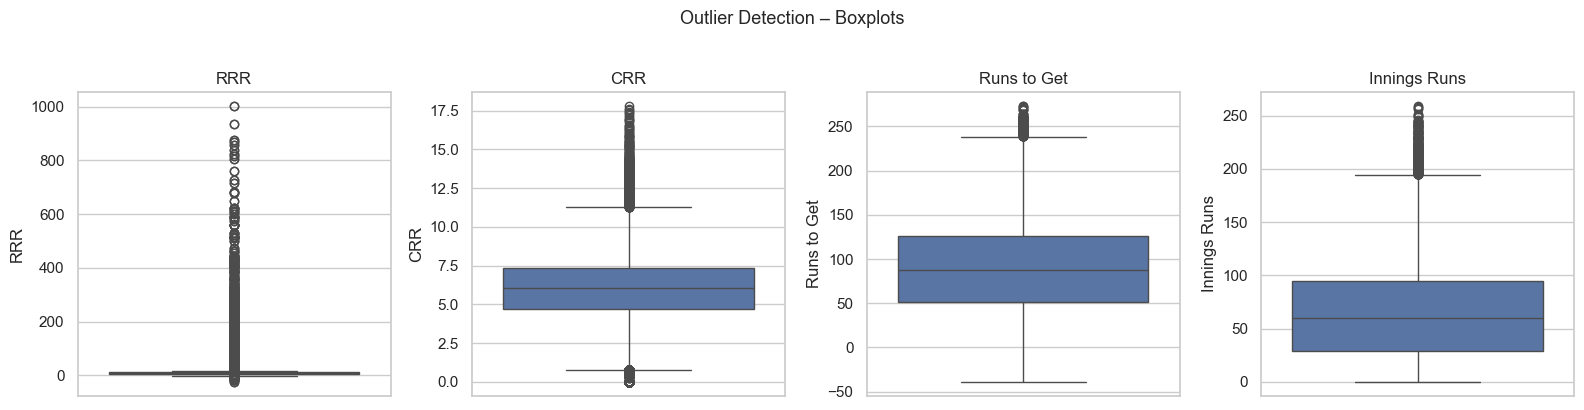

In [11]:
# Visualisation-based detection: boxplots
outlier_cols = ['RRR', 'CRR', 'Runs to Get', 'Innings Runs']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.suptitle('Outlier Detection – Boxplots', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
# IQR Capping – print full breakdown for report
print('=' * 65)
print('IQR OUTLIER ANALYSIS')
print('=' * 65)

def iqr_cap_verbose(series, col_name):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((series < lower) | (series > upper)).sum()
    capped = series.clip(lower, upper)
    print(f'\nFeature: {col_name}')
    print(f'  Q1          = {Q1:.4f}')
    print(f'  Q3          = {Q3:.4f}')
    print(f'  IQR         = {IQR:.4f}')
    print(f'  Lower Fence = {lower:.4f}  (Q1 - 1.5×IQR)')
    print(f'  Upper Fence = {upper:.4f}  (Q3 + 1.5×IQR)')
    print(f'  Outliers detected: {n_outliers:,}')
    print(f'  Treatment: CAPPING (clip to fence values)')
    return capped

for col in ['RRR', 'CRR', 'RR_Diff']:
    df[col] = iqr_cap_verbose(df[col], col)

print('\n✅ Capping applied to RRR, CRR, RR_Diff.')

IQR OUTLIER ANALYSIS

Feature: RRR
  Q1          = 6.2069
  Q3          = 10.8649
  IQR         = 4.6580
  Lower Fence = -0.7801  (Q1 - 1.5×IQR)
  Upper Fence = 17.8518  (Q3 + 1.5×IQR)
  Outliers detected: 14,792
  Treatment: CAPPING (clip to fence values)

Feature: CRR
  Q1          = 4.7143
  Q3          = 7.3469
  IQR         = 2.6327
  Lower Fence = 0.7653  (Q1 - 1.5×IQR)
  Upper Fence = 11.2959  (Q3 + 1.5×IQR)
  Outliers detected: 5,740
  Treatment: CAPPING (clip to fence values)

Feature: RR_Diff
  Q1          = -5.7627
  Q3          = 0.1297
  IQR         = 5.8924
  Lower Fence = -14.6013  (Q1 - 1.5×IQR)
  Upper Fence = 8.9684  (Q3 + 1.5×IQR)
  Outliers detected: 11,726
  Treatment: CAPPING (clip to fence values)

✅ Capping applied to RRR, CRR, RR_Diff.


In [13]:
# ── Statistical Summary [Req 7.2.1] ──────────────────────────────────────────
model_features = ['Innings Runs', 'Innings Wickets', 'Runs to Get',
                  'Balls Remaining', 'RRR', 'CRR', 'RR_Diff', 'Wickets in Hand']

print('=' * 70)
print('STATISTICAL ANALYSIS – Numerical Features (2nd Innings)')
print('=' * 70)

stat_rows = []
for col in model_features:
    s = df[col].dropna()
    stat_rows.append({
        'Feature'  : col,
        'Mean'     : round(s.mean(), 3),
        'Median'   : round(s.median(), 3),
        'Mode'     : round(s.mode()[0], 3),
        'Std Dev'  : round(s.std(), 3),
        'Variance' : round(s.var(), 3),
        'Skewness' : round(s.skew(), 3),
        'Kurtosis' : round(s.kurt(), 3),
    })

stats_df = pd.DataFrame(stat_rows).set_index('Feature')
print(stats_df.to_string())
print()
print('Interpretation:')
print('  • Mean > Median in RRR/CRR → right-skewed (high chase rates pull mean up)')
print('  • Innings Runs: roughly symmetric, most 2nd innings end near the median')
print('  • RR_Diff negative skew → chasing teams are often behind the required rate')
stats_df

STATISTICAL ANALYSIS – Numerical Features (2nd Innings)
                   Mean  Median     Mode  Std Dev  Variance  Skewness  Kurtosis
Feature                                                                        
Innings Runs     64.999  60.000    1.000   43.195  1865.826     0.485    -0.426
Innings Wickets   2.763   2.000    1.000    2.341     5.480     0.802    -0.067
Runs to Get      90.197  88.000   93.000   49.981  2498.118     0.274    -0.530
Balls Remaining  65.315  67.000  114.000   32.876  1080.822    -0.144    -1.109
RRR               8.861   8.384   17.852    4.127    17.031     0.498     0.015
CRR               5.944   6.052    6.000    2.098     4.403    -0.275     0.108
RR_Diff          -3.066  -2.796  -14.601    5.039    25.393    -0.332     0.155
Wickets in Hand   7.237   8.000    9.000    2.341     5.480    -0.802    -0.067

Interpretation:
  • Mean > Median in RRR/CRR → right-skewed (high chase rates pull mean up)
  • Innings Runs: roughly symmetric, most 2nd innin

,Mean,Median,Mode,Std Dev,Variance,Skewness,Kurtosis
Feature,,,,,,,
Innings Runs,64.999,60.000,1.000,43.195,1865.826,0.485,-0.426
Innings Wickets,2.763,2.000,1.000,2.341,5.480,0.802,-0.067
Runs to Get,90.197,88.000,93.000,49.981,2498.118,0.274,-0.530
Balls Remaining,65.315,67.000,114.000,32.876,1080.822,-0.144,-1.109
RRR,8.861,8.384,17.852,4.127,17.031,0.498,0.015
CRR,5.944,6.052,6.000,2.098,4.403,-0.275,0.108
RR_Diff,-3.066,-2.796,-14.601,5.039,25.393,-0.332,0.155
Wickets in Hand,7.237,8.000,9.000,2.341,5.480,-0.802,-0.067


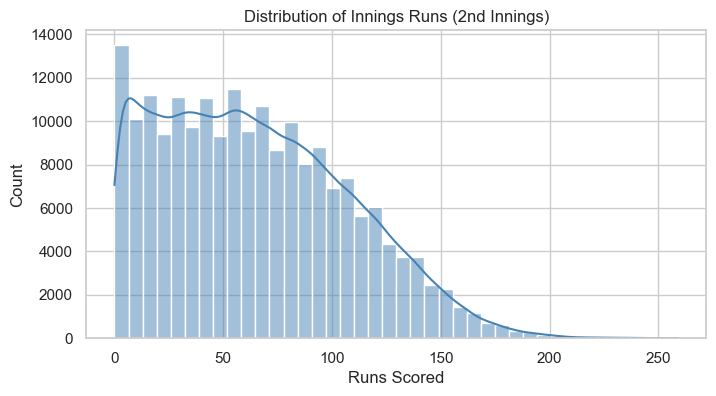

In [14]:
# ── Plot 1: Histogram of Innings Runs ────────────────────────────────────────
plt.figure(figsize=(8, 4))
sns.histplot(df['Innings Runs'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Innings Runs (2nd Innings)')
plt.xlabel('Runs Scored')
plt.savefig('hist_innings_runs.png', dpi=100, bbox_inches='tight')
plt.show()

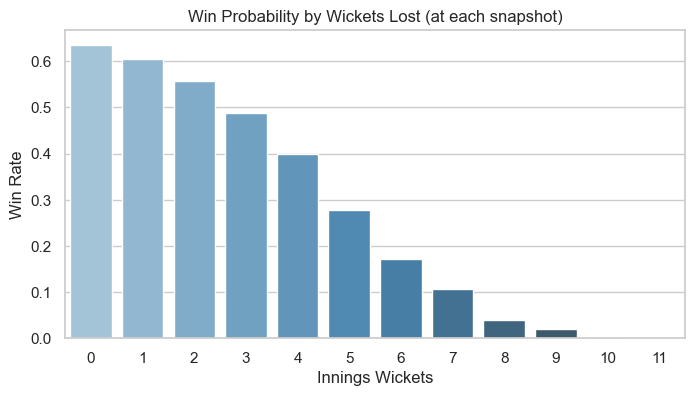

In [15]:
# ── Plot 2: Win Rate by Wickets Lost ─────────────────────────────────────────
win_by_wkt = df.groupby('Innings Wickets')['Chased Successfully'].mean().reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(data=win_by_wkt, x='Innings Wickets', y='Chased Successfully', palette='Blues_d')
plt.title('Win Probability by Wickets Lost (at each snapshot)')
plt.ylabel('Win Rate')
plt.savefig('win_rate_by_wickets.png', dpi=100, bbox_inches='tight')
plt.show()

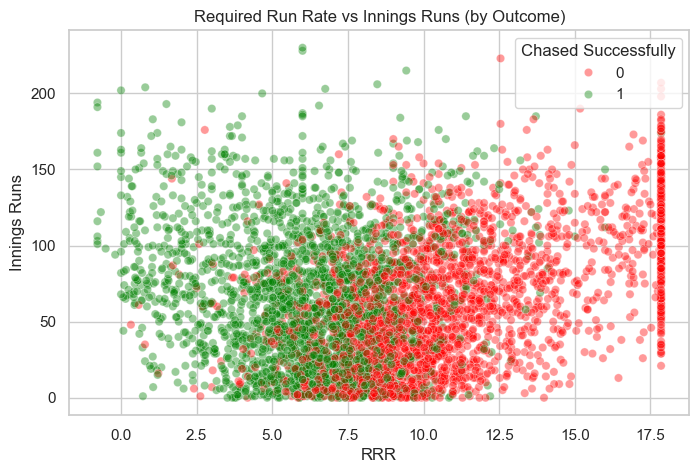

In [16]:
# ── Plot 3: Scatter – RRR vs Innings Runs coloured by outcome ─────────────────
sample = df.sample(5000, random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x='RRR', y='Innings Runs',
                hue='Chased Successfully', alpha=0.4, palette={0:'red', 1:'green'})
plt.title('Required Run Rate vs Innings Runs (by Outcome)')
plt.savefig('scatter_rrr_runs.png', dpi=100, bbox_inches='tight')
plt.show()

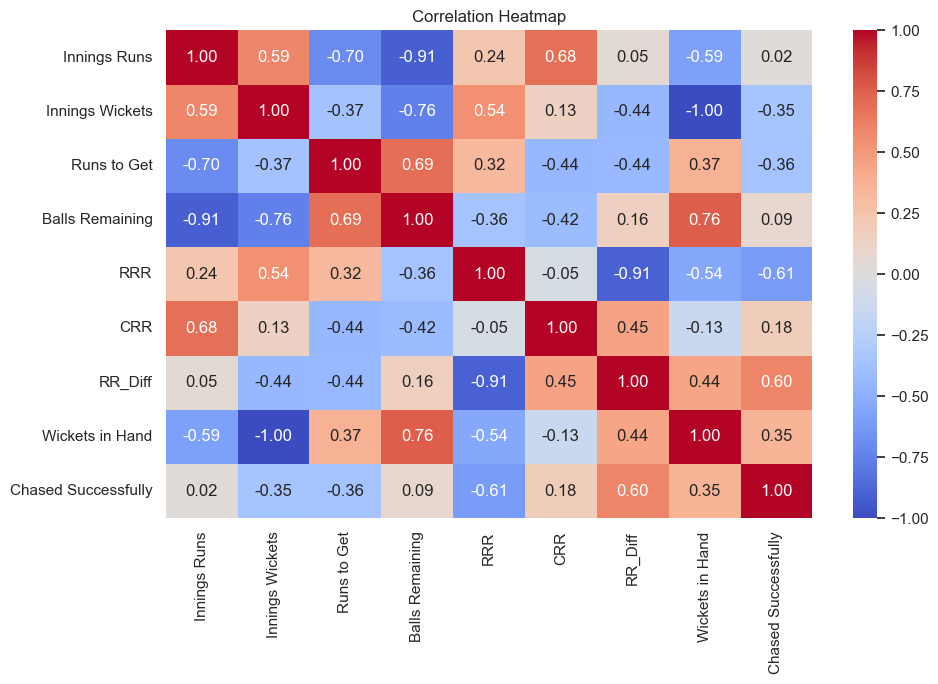

In [17]:
# ── Plot 4: Correlation Heatmap ───────────────────────────────────────────────
corr_df = df[model_features + ['Chased Successfully']].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap_corr.png', dpi=100, bbox_inches='tight')
plt.show()

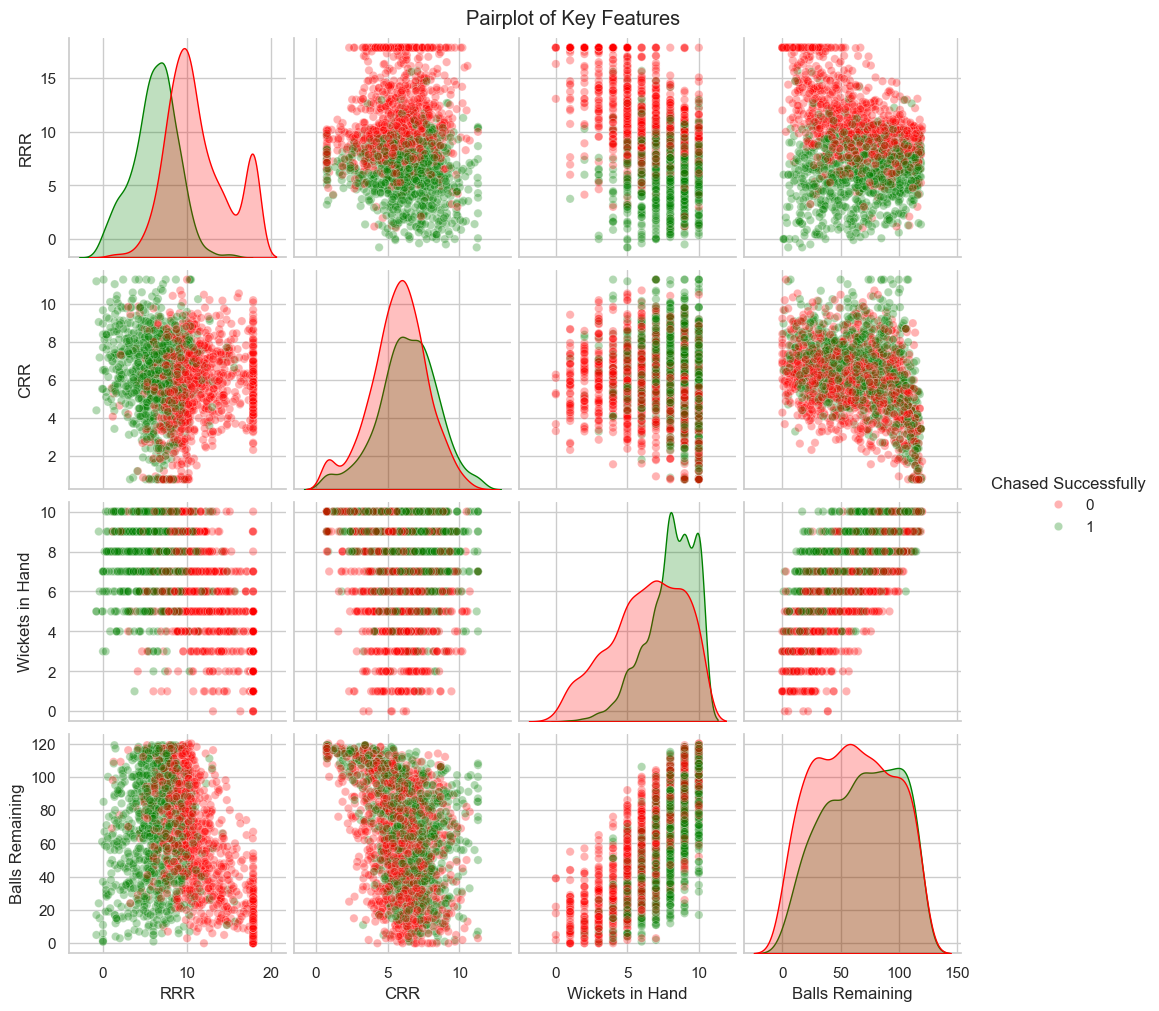

In [18]:
# ── Plot 5: Pairplot (sample) ─────────────────────────────────────────────────
pair_cols = ['RRR', 'CRR', 'Wickets in Hand', 'Balls Remaining', 'Chased Successfully']
sample2 = df[pair_cols].sample(2000, random_state=1)
pp = sns.pairplot(sample2, hue='Chased Successfully', palette={0:'red', 1:'green'},
                  plot_kws={'alpha': 0.3})
pp.fig.suptitle('Pairplot of Key Features', y=1.01)
plt.savefig('pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

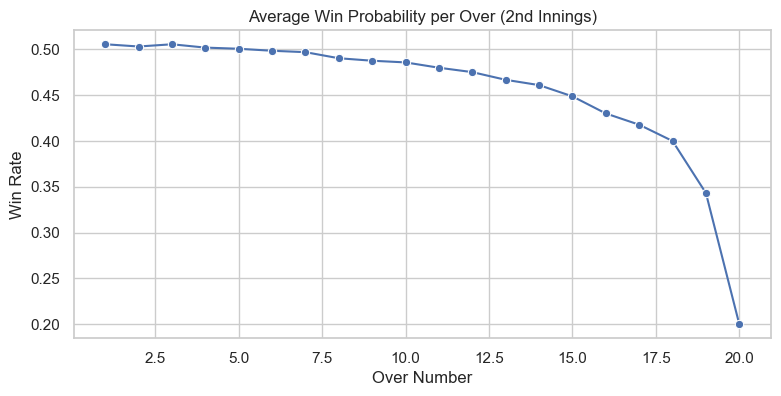

In [19]:
# ── Plot 6: Win probability over overs (time-series style) ───────────────────
win_by_over = df.groupby('Over')['Chased Successfully'].mean().reset_index()
plt.figure(figsize=(9, 4))
sns.lineplot(data=win_by_over, x='Over', y='Chased Successfully', marker='o')
plt.title('Average Win Probability per Over (2nd Innings)')
plt.ylabel('Win Rate')
plt.xlabel('Over Number')
plt.savefig('win_prob_by_over.png', dpi=100, bbox_inches='tight')
plt.show()

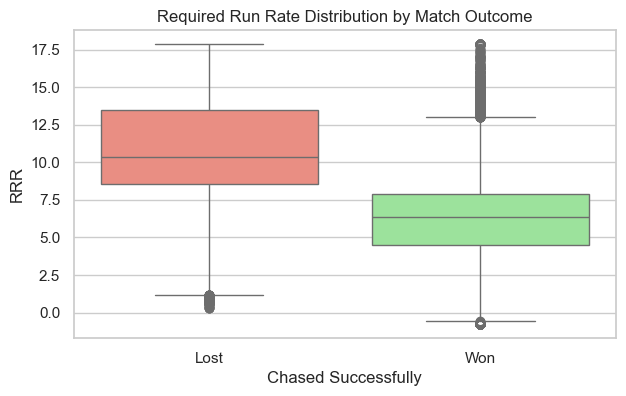

In [20]:
# ── Plot 7: Boxplot – RRR by Outcome ─────────────────────────────────────────
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Chased Successfully', y='RRR',
            palette={'0':'salmon', '1':'lightgreen'})
plt.xticks([0, 1], ['Lost', 'Won'])
plt.title('Required Run Rate Distribution by Match Outcome')
plt.savefig('boxplot_rrr_outcome.png', dpi=100, bbox_inches='tight')
plt.show()

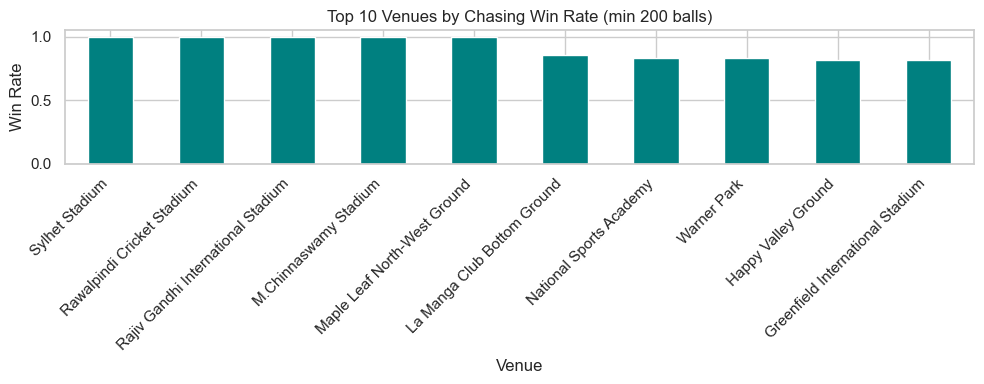

In [21]:
# ── Plot 8: Domain-specific – Top 10 venues by win rate (chasing) ─────────────
venue_win = df.groupby('Venue')['Chased Successfully'].agg(['mean', 'count'])
venue_win = venue_win[venue_win['count'] >= 200].sort_values('mean', ascending=False).head(10)
plt.figure(figsize=(10, 4))
venue_win['mean'].plot(kind='bar', color='teal')
plt.title('Top 10 Venues by Chasing Win Rate (min 200 balls)')
plt.ylabel('Win Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('venue_win_rate.png', dpi=100, bbox_inches='tight')
plt.show()

In [22]:
# ── 5 Data-Driven Insights ────────────────────────────────────────────────────
print('=== INSIGHT 1 ===')
high_rrr = df[df['RRR'] > 12]['Chased Successfully'].mean()
print(f'When RRR > 12 runs/over, chasing team wins only {high_rrr*100:.1f}% of the time.')

print('\n=== INSIGHT 2 ===')
wkt_win = df.groupby('Wickets in Hand')['Chased Successfully'].mean()
print('Win rate with 10 wickets in hand:', f"{wkt_win[10]*100:.1f}%")
print('Win rate with ≤4 wickets in hand:', f"{wkt_win[:5].mean()*100:.1f}%")

print('\n=== INSIGHT 3 ===')
last5 = df[df['Over'] >= 15]['Chased Successfully'].mean()
first5 = df[df['Over'] <= 5]['Chased Successfully'].mean()
print(f'Win rate during powerplay (overs 1-5): {first5*100:.1f}%')
print(f'Win rate in death overs (15-19): {last5*100:.1f}%')

print('\n=== INSIGHT 4 ===')
rr_diff_pos = df[df['RR_Diff'] > 0]['Chased Successfully'].mean()
rr_diff_neg = df[df['RR_Diff'] < 0]['Chased Successfully'].mean()
print(f'When CRR > RRR (ahead of rate): {rr_diff_pos*100:.1f}% win rate')
print(f'When CRR < RRR (behind rate):   {rr_diff_neg*100:.1f}% win rate')

print('\n=== INSIGHT 5 ===')
overall_chase_rate = df.drop_duplicates('Match ID')['Chased Successfully'].mean()
print(f'Overall chasing success rate across all matches: {overall_chase_rate*100:.1f}%')

=== INSIGHT 1 ===
When RRR > 12 runs/over, chasing team wins only 3.2% of the time.

=== INSIGHT 2 ===
Win rate with 10 wickets in hand: 63.6%
Win rate with ≤4 wickets in hand: 3.4%

=== INSIGHT 3 ===
Win rate during powerplay (overs 1-5): 50.3%
Win rate in death overs (15-19): 39.2%

=== INSIGHT 4 ===
When CRR > RRR (ahead of rate): 88.9% win rate
When CRR < RRR (behind rate):   32.2% win rate

=== INSIGHT 5 ===
Overall chasing success rate across all matches: 50.4%


In [23]:
# ── One-Hot Encoding ──────────────────────────────────────────────────────────
print('Before encoding – unique teams sample:')
print(df[['Bat First', 'Bat Second']].drop_duplicates().head(6).to_string(index=False))
print(f'\nUnique teams in Bat First : {df["Bat First"].nunique()}')
print(f'Unique teams in Bat Second: {df["Bat Second"].nunique()}')

df_encoded = pd.get_dummies(
    df, columns=['Bat First', 'Bat Second'],
    prefix=['BatFirst', 'BatSecond'], drop_first=False
)

ohe_cols = [c for c in df_encoded.columns
            if c.startswith('BatFirst_') or c.startswith('BatSecond_')]

print(f'\nAfter encoding – {len(ohe_cols)} new binary columns created:')
print(ohe_cols)
print(f'\nSample of 3 OHE columns (first 5 rows):')
print(df_encoded[ohe_cols[:3]].head(5).to_string())

Before encoding – unique teams sample:
   Bat First   Bat Second
     England    Australia
   Australia  New Zealand
South Africa  New Zealand
     England     Pakistan
   Sri Lanka      England
   Australia South Africa

Unique teams in Bat First : 96
Unique teams in Bat Second: 95

After encoding – 191 new binary columns created:
['BatFirst_Afghanistan', 'BatFirst_Argentina', 'BatFirst_Australia', 'BatFirst_Austria', 'BatFirst_Bahamas', 'BatFirst_Bahrain', 'BatFirst_Bangladesh', 'BatFirst_Belgium', 'BatFirst_Belize', 'BatFirst_Bermuda', 'BatFirst_Bhutan', 'BatFirst_Botswana', 'BatFirst_Bulgaria', 'BatFirst_Cameroon', 'BatFirst_Canada', 'BatFirst_Cayman Islands', 'BatFirst_China', 'BatFirst_Cook Islands', 'BatFirst_Croatia', 'BatFirst_Cyprus', 'BatFirst_Czech Republic', 'BatFirst_Denmark', 'BatFirst_England', 'BatFirst_Estonia', 'BatFirst_Eswatini', 'BatFirst_Fiji', 'BatFirst_Finland', 'BatFirst_France', 'BatFirst_Gambia', 'BatFirst_Germany', 'BatFirst_Ghana', 'BatFirst_Gibraltar', 'B

In [24]:
# ── Feature list: numerical + OHE team columns ────────────────────────────────
NUM_FEATURES = ['Innings Runs', 'Innings Wickets', 'Runs to Get',
                'Balls Remaining', 'RRR', 'CRR', 'RR_Diff', 'Wickets in Hand']
FEATURES = NUM_FEATURES + ohe_cols
TARGET   = 'Chased Successfully'

model_df = df_encoded[FEATURES + [TARGET]].dropna()
X = model_df[FEATURES].values
y = model_df[TARGET].values

# ── 70 / 15 / 15 stratified split ────────────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print('=== Data Split Summary ===')
print(f'Total samples : {len(X):,}')
print(f'Training set  : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation set: {len(X_val):,}   ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test set      : {len(X_test):,}   ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nClass balance – Train | Win: {y_train.mean()*100:.1f}%  Loss: {(1-y_train.mean())*100:.1f}%')
print(f'Class balance – Test  | Win: {y_test.mean()*100:.1f}%  Loss: {(1-y_test.mean())*100:.1f}%')

=== Data Split Summary ===
Total samples : 199,746
Training set  : 139,817  (70.0%)
Validation set: 29,967   (15.0%)
Test set      : 29,962   (15.0%)

Class balance – Train | Win: 46.9%  Loss: 53.1%
Class balance – Test  | Win: 46.9%  Loss: 53.1%


In [25]:
# ── Standardization – Before vs After ────────────────────────────────────────
print('BEFORE Standardization (3 numerical features, first 5 rows):')
print(pd.DataFrame(X_train[:5, :3], columns=NUM_FEATURES[:3]).round(3).to_string(index=False))

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('\nAFTER Standardization (same rows and columns):')
print(pd.DataFrame(X_train_sc[:5, :3], columns=NUM_FEATURES[:3]).round(3).to_string(index=False))

print('\nMean of each feature after scaling (should be ≈ 0):')
print(pd.Series(X_train_sc[:, :3].mean(axis=0), index=NUM_FEATURES[:3]).round(6).to_string())
print('\nStd of each feature after scaling (should be ≈ 1):')
print(pd.Series(X_train_sc[:, :3].std(axis=0),  index=NUM_FEATURES[:3]).round(6).to_string())

BEFORE Standardization (3 numerical features, first 5 rows):
Innings Runs Innings Wickets Runs to Get
          41               2       116.0
         113               7        36.0
          25               0       190.0
         103               0        98.0
         106               6       109.0

AFTER Standardization (same rows and columns):
 Innings Runs  Innings Wickets  Runs to Get
       -0.552           -0.322        0.514
        1.121            1.824       -1.089
       -0.924           -1.180        1.996
        0.889           -1.180        0.153
        0.958            1.395        0.373

Mean of each feature after scaling (should be ≈ 0):
Innings Runs       0.0
Innings Wickets    0.0
Runs to Get       -0.0

Std of each feature after scaling (should be ≈ 1):
Innings Runs       1.0
Innings Wickets    1.0
Runs to Get        1.0


Top 15 Features by Mutual Information Score:
RRR                     0.2596
RR_Diff                 0.2552
Runs to Get             0.0774
Wickets in Hand         0.0749
Innings Wickets         0.0744
CRR                     0.0350
BatSecond_India         0.0074
BatSecond_Zimbabwe      0.0073
BatFirst_India          0.0070
BatFirst_Pakistan       0.0067
BatFirst_Oman           0.0058
Balls Remaining         0.0050
BatFirst_Gibraltar      0.0048
BatSecond_Lesotho       0.0047
BatSecond_Bangladesh    0.0047


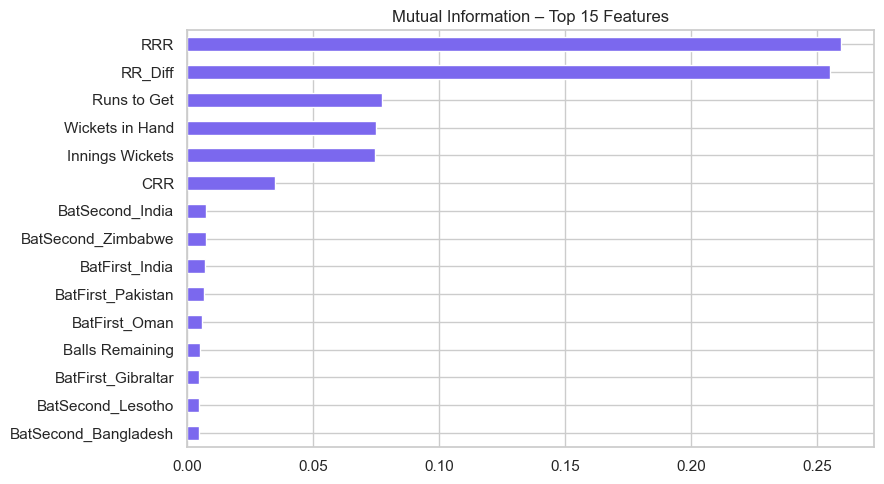


Features selected (MI >= 0.001): 137
Feature selection applied.
X_train_sc shape after selection: (139817, 137)


In [26]:
# Mutual Information – show top 15 features
# Use FEATURES list that matches X_train_sc dimensions
actual_features = FEATURES[:X_train_sc.shape[1]]  # align lengths

mi_scores = mutual_info_classif(X_train_sc, y_train, random_state=42)
mi_df = pd.Series(mi_scores, index=actual_features).sort_values(ascending=False)
print('Top 15 Features by Mutual Information Score:')
print(mi_df.head(15).round(4).to_string())

plt.figure(figsize=(9, 5))
mi_df.head(15).sort_values().plot(kind='barh', color='mediumslateblue')
plt.title('Mutual Information – Top 15 Features')
plt.tight_layout()
plt.savefig('feature_importance_mi.png', dpi=100, bbox_inches='tight')
plt.show()

# Drop low-MI features (threshold = 0.001) to keep model lean
selected_features = mi_df[mi_df >= 0.001].index.tolist()
selected_indices  = [actual_features.index(f) for f in selected_features]
print(f'\nFeatures selected (MI >= 0.001): {len(selected_features)}')

X_train_sc = X_train_sc[:, selected_indices]
X_val_sc   = X_val_sc[:,   selected_indices]
X_test_sc  = X_test_sc[:,  selected_indices]
FEATURES_SELECTED = selected_features
print('Feature selection applied.')
print(f'X_train_sc shape after selection: {X_train_sc.shape}')

In [27]:
pca = PCA(n_components=0.95, random_state=42)  # keep 95% variance
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca   = pca.transform(X_val_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f'Original features: {X_train_sc.shape[1]}')
print(f'After PCA (95% variance): {X_train_pca.shape[1]} components')
print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(3)}')

Original features: 137
After PCA (95% variance): 117 components
Explained variance ratio: [0.026 0.019 0.014 0.013 0.013 0.012 0.012 0.012 0.011 0.011 0.011 0.011
 0.011 0.011 0.011 0.011 0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01
 0.01  0.01  0.01  0.01  0.009 0.009 0.009 0.009 0.009 0.009 0.009 0.009
 0.009 0.009 0.009 0.009 0.009 0.009 0.009 0.009 0.008 0.008 0.008 0.008
 0.008 0.008 0.008 0.008 0.008 0.008 0.008 0.008 0.008 0.008 0.008 0.008
 0.008 0.007 0.007 0.007 0.007 0.007 0.007 0.007 0.007 0.007 0.007 0.007
 0.007 0.007 0.007 0.007 0.007 0.007 0.007 0.007 0.007 0.007 0.007 0.007
 0.007 0.006 0.006 0.006 0.006 0.006 0.006 0.006 0.006 0.006 0.006 0.006
 0.006 0.006 0.006 0.006 0.006 0.006 0.005 0.005 0.005 0.005 0.005 0.005
 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.004 0.004]


In [28]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────────
# Grid Search for best C
lr_params = {'C': [0.01, 0.1, 1, 10]}
lr_gs = GridSearchCV(LogisticRegression(max_iter=500, random_state=42),
                     lr_params, cv=5, scoring='f1', n_jobs=-1)
lr_gs.fit(X_train_sc, y_train)
best_lr = lr_gs.best_estimator_
print('Best LR params:', lr_gs.best_params_)

# Cross-validation
lr_cv = cross_val_score(best_lr, X_train_sc, y_train, cv=5, scoring='accuracy')
print(f'LR 5-fold CV Accuracy: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')

Best LR params: {'C': 0.01}
LR 5-fold CV Accuracy: 0.8525 ± 0.0019


In [30]:
# ── Model 2: Random Forest ────────────────────────────────────────────────────
rf_params = {'n_estimators': [50], 'max_depth': [10]}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=42),
                     rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_gs.fit(X_train_sc, y_train)
best_rf = rf_gs.best_estimator_
print('Best RF params:', rf_gs.best_params_)

rf_cv = cross_val_score(best_rf, X_train_sc, y_train, cv=5, scoring='accuracy')
print(f'RF 5-fold CV Accuracy: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

Best RF params: {'max_depth': 10, 'n_estimators': 50}
RF 5-fold CV Accuracy: 0.8437 ± 0.0027


In [31]:
def evaluate(name, model, X_t, y_t):
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    acc  = accuracy_score(y_t, y_pred)
    prec = precision_score(y_t, y_pred)
    rec  = recall_score(y_t, y_pred)
    f1   = f1_score(y_t, y_pred)
    auc  = roc_auc_score(y_t, y_prob)
    print(f'\n=== {name} ===')
    print(f'Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}')
    print(classification_report(y_t, y_pred, target_names=['Lost','Won']))
    return dict(Model=name, Accuracy=acc, Precision=prec, Recall=rec, F1=f1, AUC=auc), y_prob

res_lr, prob_lr = evaluate('Logistic Regression', best_lr, X_test_sc, y_test)
res_rf, prob_rf = evaluate('Random Forest',       best_rf, X_test_sc, y_test)


=== Logistic Regression ===
Accuracy=0.8479  Precision=0.8374  Recall=0.8388  F1=0.8381  AUC=0.9313
              precision    recall  f1-score   support

        Lost       0.86      0.86      0.86     15900
         Won       0.84      0.84      0.84     14062

    accuracy                           0.85     29962
   macro avg       0.85      0.85      0.85     29962
weighted avg       0.85      0.85      0.85     29962


=== Random Forest ===
Accuracy=0.8384  Precision=0.8291  Recall=0.8260  F1=0.8275  AUC=0.9264
              precision    recall  f1-score   support

        Lost       0.85      0.85      0.85     15900
         Won       0.83      0.83      0.83     14062

    accuracy                           0.84     29962
   macro avg       0.84      0.84      0.84     29962
weighted avg       0.84      0.84      0.84     29962



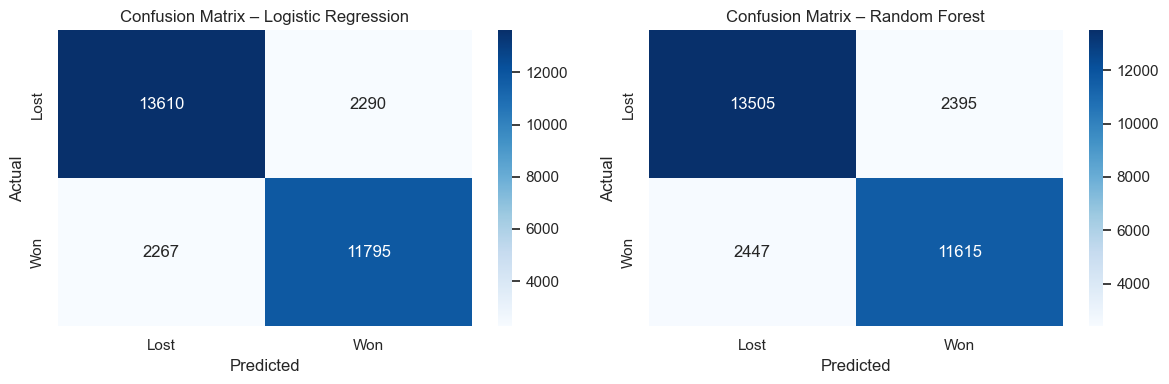

In [32]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, model) in zip(axes, [('Logistic Regression', best_lr), ('Random Forest', best_rf)]):
    cm = confusion_matrix(y_test, model.predict(X_test_sc))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Lost','Won'], yticklabels=['Lost','Won'])
    ax.set_title(f'Confusion Matrix – {name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

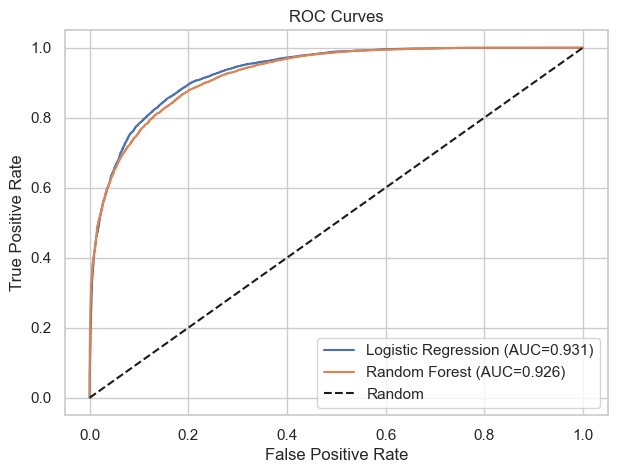

In [33]:
# ROC Curves
plt.figure(figsize=(7, 5))
for name, probs in [('Logistic Regression', prob_lr), ('Random Forest', prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.savefig('roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [34]:
# Comparison Table
comparison = pd.DataFrame([res_lr, res_rf]).set_index('Model').round(4)
print('\n=== Model Comparison Table ===')
comparison


=== Model Comparison Table ===


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.8479,0.8374,0.8388,0.8381,0.9313
Random Forest,0.8384,0.8291,0.8260,0.8275,0.9264


In [35]:
# PCA comparison – quick accuracy check
lr_pca = LogisticRegression(C=lr_gs.best_params_['C'], max_iter=500).fit(X_train_pca, y_train)
rf_pca = RandomForestClassifier(**rf_gs.best_params_, random_state=42).fit(X_train_pca, y_train)
print('Accuracy without PCA – LR:', accuracy_score(y_test, best_lr.predict(X_test_sc)))
print('Accuracy with PCA    – LR:', accuracy_score(y_test, lr_pca.predict(X_test_pca)))
print('Accuracy without PCA – RF:', accuracy_score(y_test, best_rf.predict(X_test_sc)))
print('Accuracy with PCA    – RF:', accuracy_score(y_test, rf_pca.predict(X_test_pca)))


Accuracy without PCA – LR: 0.8479073493091249
Accuracy with PCA    – LR: 0.8404979640878446
Accuracy without PCA – RF: 0.8383953007142381
Accuracy with PCA    – RF: 0.9244042453774781


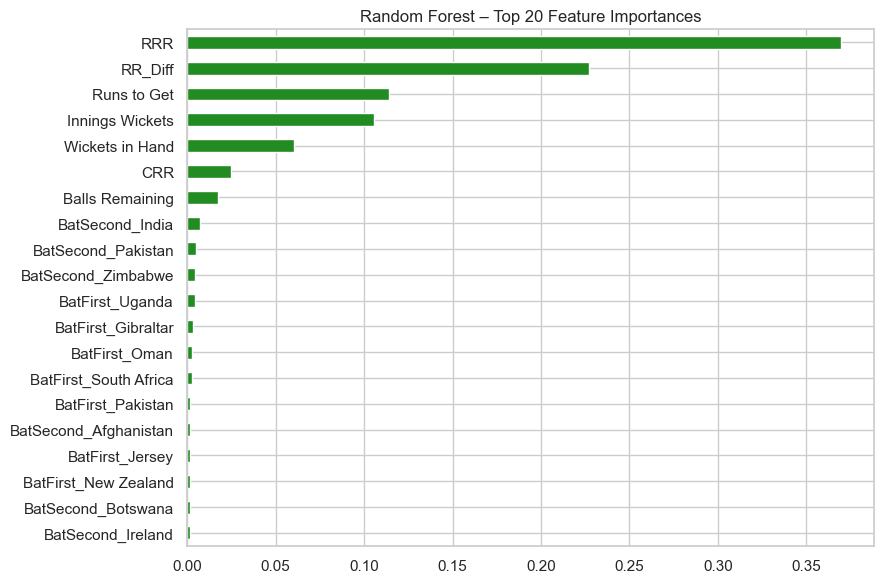

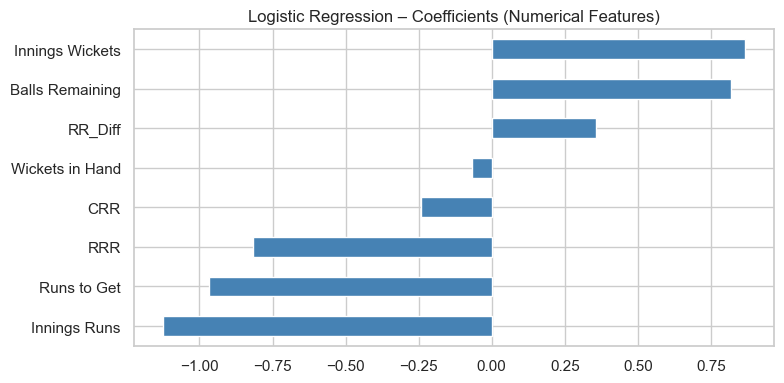


Top 5 most important features (Random Forest):
RRR                0.369796
RR_Diff            0.226929
Runs to Get        0.113863
Innings Wickets    0.105626
Wickets in Hand    0.060397


In [36]:
# Random Forest feature importances – top 20 for readability
fi_all = pd.Series(best_rf.feature_importances_, index=FEATURES_SELECTED).sort_values(ascending=False)
fi_top = fi_all.head(20).sort_values(ascending=True)
plt.figure(figsize=(9, 6))
fi_top.plot(kind='barh', color='forestgreen')
plt.title('Random Forest – Top 20 Feature Importances')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# Logistic Regression coefficients – numerical features only for clarity
lr_coefs = pd.Series(best_lr.coef_[0][:len(NUM_FEATURES)], index=NUM_FEATURES).sort_values(ascending=True)
plt.figure(figsize=(8, 4))
lr_coefs.plot(kind='barh', color='steelblue')
plt.title('Logistic Regression – Coefficients (Numerical Features)')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features (Random Forest):')
print(fi_all.head(5).to_string())

In [49]:
# Export processed data + predictions for Power BI
export_df = model_df.copy()

# Scale and select features exactly as done during training
X_all_sc = scaler.transform(model_df[FEATURES].values)
X_all_sc = X_all_sc[:, selected_indices]

# Predict using both models
export_df['LR_Win_Prob']       = best_lr.predict_proba(X_all_sc)[:, 1]
export_df['RF_Win_Prob']       = best_rf.predict_proba(X_all_sc)[:, 1]
export_df['LR_Predicted']      = best_lr.predict(X_all_sc)
export_df['RF_Predicted']      = best_rf.predict(X_all_sc)
export_df['Ensemble_Win_Prob'] = (export_df['LR_Win_Prob'] + export_df['RF_Win_Prob']) / 2

# Drop OHE team columns – not needed in Power BI
ohe_to_drop = [c for c in export_df.columns if c.startswith('BatFirst_') or c.startswith('BatSecond_')]
export_df.drop(columns=ohe_to_drop, inplace=True)

# Pull context columns from df
context_from_df = df[['Match ID', 'Date', 'Venue', 'Over', 'Ball',
                       'Winner']].loc[export_df.index]

# Pull Bat First, Bat Second, Target Score, Batter, Bowler from df_raw
context_from_raw = df_raw[['Bat First', 'Bat Second', 'Target Score',
                            'Batter', 'Bowler']].loc[export_df.index]

export_df = export_df.join(context_from_df, how='left')
export_df = export_df.join(context_from_raw, how='left')

# Add Match Score String for easy reading in Power BI
export_df['Score'] = export_df['Innings Runs'].astype(str) + '/' + export_df['Innings Wickets'].astype(str)

# Categorize matches as High/Medium/Low scoring based on Target Score
export_df['Match Type'] = pd.cut(
    export_df['Target Score'],
    bins=[0, 150, 180, 999],
    labels=['Low Scoring (<150)', 'Medium (150-180)', 'High Scoring (180+)']
)

# Fix Date column to proper datetime for Power BI time intelligence
export_df['Date'] = pd.to_datetime(export_df['Date'])

# Fix Match ID – ensure it's a string so Power BI doesn't summarize it
export_df['Match ID'] = export_df['Match ID'].astype(str)

# Prediction correctness column – useful for accuracy analysis in Power BI
export_df['RF_Correct'] = (export_df['RF_Predicted'] == export_df['Chased Successfully']).astype(int)
export_df['LR_Correct'] = (export_df['LR_Predicted'] == export_df['Chased Successfully']).astype(int)

export_df.to_csv('processed_for_powerbi.csv', index=False)
print(f'Exported {len(export_df):,} rows to modified_powerbi.csv')
print(f'Columns: {export_df.columns.tolist()}')
export_df.head()

Exported 199,746 rows to modified_powerbi.csv
Columns: ['Innings Runs', 'Innings Wickets', 'Runs to Get', 'Balls Remaining', 'RRR', 'CRR', 'RR_Diff', 'Wickets in Hand', 'Chased Successfully', 'LR_Win_Prob', 'RF_Win_Prob', 'LR_Predicted', 'RF_Predicted', 'Ensemble_Win_Prob', 'Match ID', 'Date', 'Venue', 'Over', 'Ball', 'Winner', 'Bat First', 'Bat Second', 'Target Score', 'Batter', 'Bowler', 'Score', 'Match Type', 'RF_Correct', 'LR_Correct']


,Innings Runs,Innings Wickets,Runs to Get,Balls Remaining,RRR,CRR,RR_Diff,Wickets in Hand,Chased Successfully,LR_Win_Prob,...,Winner,Bat First,Bat Second,Target Score,Batter,Bowler,Score,Match Type,RF_Correct,LR_Correct
66004,0,0,180.0,119,9.075630,0.765306,-9.075630,10,0,0.146734,...,England,England,Australia,180,AC Gilchrist,D Gough,0/0,Medium (150-180),1,1
66005,4,0,176.0,118,8.949153,3.000000,-5.949153,10,0,0.205808,...,England,England,Australia,180,AC Gilchrist,D Gough,4/0,Medium (150-180),1,1
66006,4,0,176.0,117,9.025641,2.666667,-6.358974,10,0,0.200106,...,England,England,Australia,180,AC Gilchrist,D Gough,4/0,Medium (150-180),1,1
66007,4,0,176.0,116,9.103448,2.400000,-6.703448,10,0,0.195024,...,England,England,Australia,180,AC Gilchrist,D Gough,4/0,Medium (150-180),1,1
66008,8,0,172.0,115,8.973913,4.363636,-4.610277,10,0,0.239891,...,England,England,Australia,180,AC Gilchrist,D Gough,8/0,Medium (150-180),1,1


In [38]:
joblib.dump(best_lr, 'model_logistic_regression.pkl')
joblib.dump(best_rf, 'model_random_forest.pkl')
joblib.dump(scaler,  'scaler.pkl')
print('Models and scaler saved!')

Models and scaler saved!


In [41]:
# ── Win Probability Predictor ──────────────────────────────────────────────────

def build_input_row(innings_runs, innings_wickets, runs_to_get,
                    balls_remaining, bat_first_team, bat_second_team):
    balls_bowled    = 120 - balls_remaining
    crr             = (innings_runs / balls_bowled * 6) if balls_bowled > 0 else 0
    rrr             = (runs_to_get  / balls_remaining * 6) if balls_remaining > 0 else 99
    rr_diff         = crr - rrr
    wickets_in_hand = 10 - innings_wickets

    # Build row with full FEATURES list (199 columns)
    row = {f: 0 for f in FEATURES}
    row['Innings Runs']    = innings_runs
    row['Innings Wickets'] = innings_wickets
    row['Runs to Get']     = runs_to_get
    row['Balls Remaining'] = balls_remaining
    row['RRR']             = rrr
    row['CRR']             = crr
    row['RR_Diff']         = rr_diff
    row['Wickets in Hand'] = wickets_in_hand

    bf_col = f'BatFirst_{bat_first_team}'
    bs_col = f'BatSecond_{bat_second_team}'
    if bf_col in row:
        row[bf_col] = 1
    else:
        print(f"⚠️  Warning: '{bat_first_team}' not in training data — treated as unseen team")
    if bs_col in row:
        row[bs_col] = 1
    else:
        print(f"⚠️  Warning: '{bat_second_team}' not in training data — treated as unseen team")

    # Scale with full 199 features, then filter to selected_indices (137)
    row_df = pd.DataFrame([row])[FEATURES]
    row_sc = scaler.transform(row_df)
    row_sc = row_sc[:, selected_indices]
    return row_sc


def predict_win_probability(innings_runs, innings_wickets, runs_to_get,
                             balls_remaining, bat_first_team, bat_second_team):
    over         = (120 - balls_remaining) // 6
    ball         = (120 - balls_remaining) % 6
    balls_bowled = 120 - balls_remaining
    crr          = (innings_runs / balls_bowled * 6) if balls_bowled > 0 else 0
    rrr          = (runs_to_get  / balls_remaining * 6) if balls_remaining > 0 else 99

    row_sc  = build_input_row(innings_runs, innings_wickets, runs_to_get,
                               balls_remaining, bat_first_team, bat_second_team)

    lr_prob = best_lr.predict_proba(row_sc)[0][1]
    rf_prob = best_rf.predict_proba(row_sc)[0][1]
    avg     = (lr_prob + rf_prob) / 2
    verdict = 'WIN ✅' if avg >= 0.5 else 'LOSS ❌'

    print('=' * 55)
    print('        🏏 T20 WIN PROBABILITY PREDICTOR')
    print('=' * 55)
    print(f'  Batting (Chasing) : {bat_second_team}')
    print(f'  Bowling (Set)     : {bat_first_team}')
    print(f'  Situation         : Over {over}.{ball}')
    print(f'  Score             : {innings_runs}/{innings_wickets}')
    print(f'  Need              : {runs_to_get} off {balls_remaining} balls')
    print(f'  CRR / RRR         : {crr:.2f} / {rrr:.2f}')
    print('-' * 55)
    print(f'  Logistic Regression : {lr_prob*100:.1f}%')
    print(f'  Random Forest       : {rf_prob*100:.1f}%')
    print(f'  Ensemble Average    : {avg*100:.1f}%')
    print('-' * 55)
    print(f'  🏆 Predicted Result : Chasing team → {verdict}')
    print('=' * 55)


# ✏️ EDIT THESE VALUES to match your match situation
predict_win_probability(
    innings_runs    = 87,
    innings_wickets = 3,
    runs_to_get     = 54,
    balls_remaining = 42,
    bat_first_team  = 'India',
    bat_second_team = 'Pakistan'
)

        🏏 T20 WIN PROBABILITY PREDICTOR
  Batting (Chasing) : Pakistan
  Bowling (Set)     : India
  Situation         : Over 13.0
  Score             : 87/3
  Need              : 54 off 42 balls
  CRR / RRR         : 6.69 / 7.71
-------------------------------------------------------
  Logistic Regression : 86.0%
  Random Forest       : 79.5%
  Ensemble Average    : 82.7%
-------------------------------------------------------
  🏆 Predicted Result : Chasing team → WIN ✅


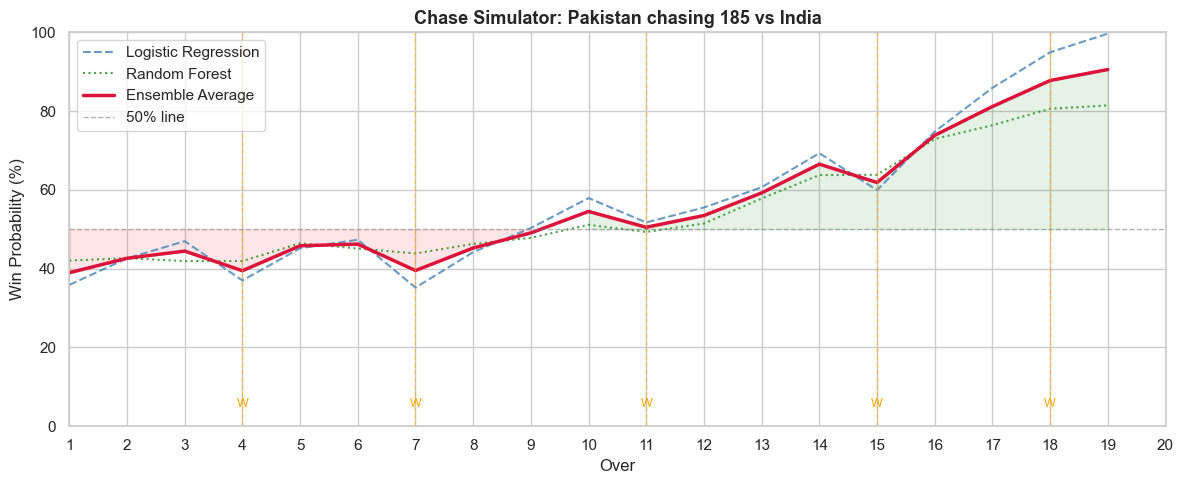

Final win probability: 90.6% → Pakistan predicted to WIN ✅


In [42]:
def simulate_chase(target, bat_first_team, bat_second_team,
                   runs_per_over=None, wicket_overs=None):
    runs_needed = target
    if runs_per_over is None:
        runs_per_over = [round(runs_needed / 20)] * 20
    if wicket_overs is None:
        wicket_overs = [3, 7, 11, 15, 18]

    overs_list, lr_probs, rf_probs, avg_probs = [], [], [], []
    innings_runs    = 0
    innings_wickets = 0

    for over in range(20):
        innings_runs += runs_per_over[over]
        if over in wicket_overs:
            innings_wickets = min(innings_wickets + 1, 10)

        balls_done      = (over + 1) * 6
        balls_remaining = max(120 - balls_done, 1)
        runs_to_get     = max(target - innings_runs, 0)

        row_sc = build_input_row(innings_runs, innings_wickets, runs_to_get,
                                  balls_remaining, bat_first_team, bat_second_team)

        lr_p = best_lr.predict_proba(row_sc)[0][1]
        rf_p = best_rf.predict_proba(row_sc)[0][1]

        overs_list.append(over + 1)
        lr_probs.append(lr_p * 100)
        rf_probs.append(rf_p * 100)
        avg_probs.append((lr_p + rf_p) / 2 * 100)

        if runs_to_get <= 0:
            break

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(overs_list, lr_probs,  label='Logistic Regression',
            linestyle='--', color='steelblue',   linewidth=1.5, alpha=0.8)
    ax.plot(overs_list, rf_probs,  label='Random Forest',
            linestyle=':',  color='forestgreen', linewidth=1.5, alpha=0.8)
    ax.plot(overs_list, avg_probs, label='Ensemble Average',
            color='crimson', linewidth=2.5)

    for wo in wicket_overs:
        if wo + 1 <= len(overs_list):
            ax.axvline(x=wo+1, color='orange', linestyle='--', alpha=0.5, linewidth=1)
            ax.text(wo+1, 5, 'W', color='orange', fontsize=9, ha='center')

    ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='50% line')
    ax.fill_between(overs_list, avg_probs, 50,
                    where=[p >= 50 for p in avg_probs], alpha=0.1, color='green')
    ax.fill_between(overs_list, avg_probs, 50,
                    where=[p < 50 for p in avg_probs],  alpha=0.1, color='red')

    ax.set_xlim(1, 20)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Over', fontsize=12)
    ax.set_ylabel('Win Probability (%)', fontsize=12)
    ax.set_title(f'Chase Simulator: {bat_second_team} chasing {target} vs {bat_first_team}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper left')
    ax.set_xticks(range(1, 21))
    plt.tight_layout()
    plt.savefig('chase_simulator.png', dpi=120, bbox_inches='tight')
    plt.show()

    final = avg_probs[-1]
    print(f'Final win probability: {final:.1f}% → {bat_second_team} predicted to {"WIN ✅" if final>=50 else "LOSE ❌"}')


# ✏️ EDIT THESE VALUES
simulate_chase(
    target          = 185,
    bat_first_team  = 'India',
    bat_second_team = 'Pakistan',
    runs_per_over   = [6, 8, 7, 9, 10, 6, 8, 11, 9, 10,
                       12, 8, 9, 11, 10, 13, 12, 15, 11, 14],
    wicket_overs    = [3, 6, 10, 14, 17]
)

In [43]:
inn2 = df_raw[df_raw['Innings'] == 2].copy()
match_list = (
    inn2.drop_duplicates('Match ID')[['Match ID','Date','Bat First','Bat Second','Venue','Target Score','Winner']]
    .sort_values('Date', ascending=False)
    .reset_index(drop=True)
)
print('Recent matches in dataset (most recent first):')
print(match_list.head(15).to_string(index=False))

Recent matches in dataset (most recent first):
 Match ID       Date   Bat First           Bat Second                                 Venue  Target Score               Winner
  1393328 2023-08-22      Rwanda             Tanzania Gahanga International Cricket Stadium           155             Tanzania
  1393312 2023-08-22      Uganda               Rwanda Gahanga International Cricket Stadium           187               Uganda
  1393311 2023-08-21      Uganda             Tanzania Gahanga International Cricket Stadium           177             Tanzania
  1393309 2023-08-20      Uganda               Rwanda Gahanga International Cricket Stadium           147               Uganda
  1393310 2023-08-20    Tanzania               Uganda Gahanga International Cricket Stadium           144               Uganda
  1391337 2023-08-20     Romania                Malta          Moara Vlasiei Cricket Ground           191              Romania
  1384637 2023-08-20       India              Ireland           

  Match ID : 1381220  |  Date: 2023-08-12
  Venue    : Central Broward Regional Park Stadium Turf Ground
  Chasing  : India need 179  |  Bowling: West Indies
  Result   : India WON ✅


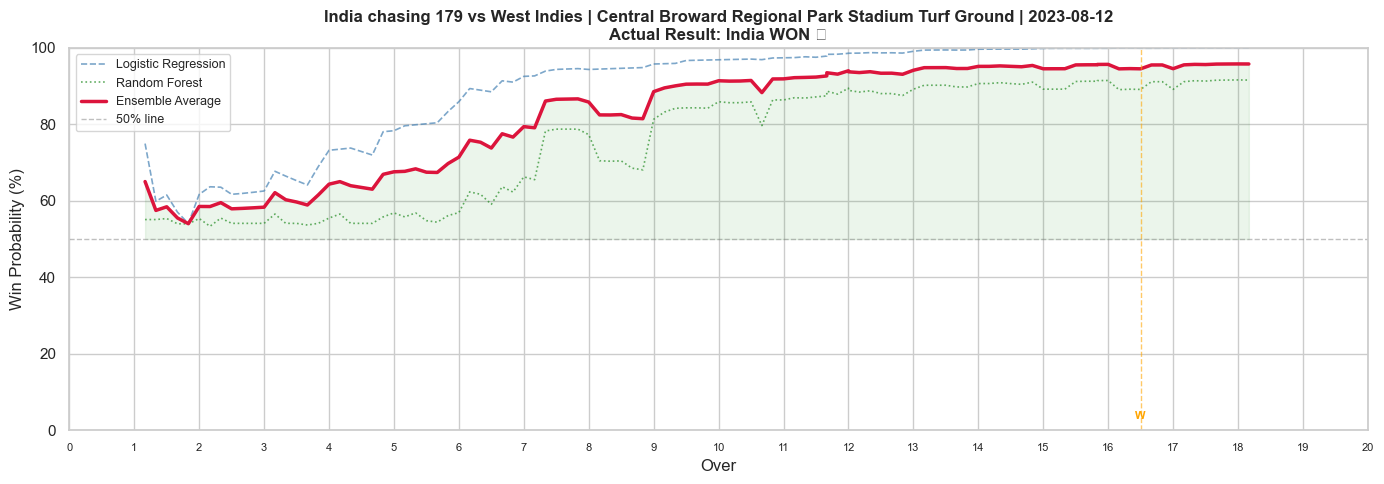

Final ensemble win probability: 95.8%
Actual result: India WON ✅


In [44]:
def replay_match(match_id):
    match = df_raw[(df_raw['Match ID'] == match_id) & (df_raw['Innings'] == 2)].copy()
    match = match.sort_values(['Over', 'Ball']).reset_index(drop=True)

    if match.empty:
        print(f'Match ID {match_id} not found.')
        return

    bat_first  = match['Bat First'].iloc[0]
    bat_second = match['Bat Second'].iloc[0]
    venue      = match['Venue'].iloc[0]
    date       = match['Date'].iloc[0]
    target     = match['Target Score'].iloc[0]
    winner     = match['Winner'].iloc[0]
    result     = 'WON ✅' if winner == bat_second else 'LOST ❌'

    print('=' * 60)
    print(f'  Match ID : {match_id}  |  Date: {date}')
    print(f'  Venue    : {venue}')
    print(f'  Chasing  : {bat_second} need {target}  |  Bowling: {bat_first}')
    print(f'  Result   : {bat_second} {result}')
    print('=' * 60)

    ball_labels, lr_probs, rf_probs, avg_probs, wicket_balls = [], [], [], [], []

    for _, row in match.iterrows():
        innings_runs    = row['Innings Runs']
        innings_wickets = row['Innings Wickets']
        runs_to_get     = row['Runs to Get'] if pd.notna(row['Runs to Get']) else 0
        balls_remaining = max(int(row['Balls Remaining']), 1) if pd.notna(row['Balls Remaining']) else 1

        row_sc = build_input_row(innings_runs, innings_wickets, runs_to_get,
                                  balls_remaining, bat_first, bat_second)

        lr_p = best_lr.predict_proba(row_sc)[0][1]
        rf_p = best_rf.predict_proba(row_sc)[0][1]

        ball_label = int(row['Over']) * 6 + int(row['Ball'])
        ball_labels.append(ball_label)
        lr_probs.append(lr_p * 100)
        rf_probs.append(rf_p * 100)
        avg_probs.append((lr_p + rf_p) / 2 * 100)

        if row['Wicket'] == 1:
            wicket_balls.append(ball_label)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(ball_labels, lr_probs,  label='Logistic Regression',
            linestyle='--', color='steelblue',   linewidth=1.2, alpha=0.7)
    ax.plot(ball_labels, rf_probs,  label='Random Forest',
            linestyle=':',  color='forestgreen', linewidth=1.2, alpha=0.7)
    ax.plot(ball_labels, avg_probs, label='Ensemble Average',
            color='crimson', linewidth=2.5)

    for wb in wicket_balls:
        ax.axvline(x=wb, color='orange', linestyle='--', alpha=0.6, linewidth=1)
        ax.text(wb, 3, 'W', color='orange', fontsize=8, ha='center', fontweight='bold')

    for ov in range(0, 121, 6):
        ax.axvline(x=ov, color='lightgray', linewidth=0.5, zorder=0)

    ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='50% line')
    ax.fill_between(ball_labels, avg_probs, 50,
                    where=[p >= 50 for p in avg_probs], alpha=0.08, color='green')
    ax.fill_between(ball_labels, avg_probs, 50,
                    where=[p < 50 for p in avg_probs],  alpha=0.08, color='red')

    ax.set_xticks(range(0, 121, 6))
    ax.set_xticklabels([str(o) for o in range(0, 21)], fontsize=8)
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Over', fontsize=12)
    ax.set_ylabel('Win Probability (%)', fontsize=12)
    ax.set_title(
        f'{bat_second} chasing {target} vs {bat_first} | {venue} | {date}\n'
        f'Actual Result: {bat_second} {result}',
        fontsize=12, fontweight='bold'
    )
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'match_replay_{match_id}.png', dpi=120, bbox_inches='tight')
    plt.show()

    print(f'Final ensemble win probability: {avg_probs[-1]:.1f}%')
    print(f'Actual result: {bat_second} {result}')


# ✏️ Change to any Match ID from the list above
replay_match( 1381220)

In [51]:
print(fi_all.head(10))

RRR                   0.369796
RR_Diff               0.226929
Runs to Get           0.113863
Innings Wickets       0.105626
Wickets in Hand       0.060397
CRR                   0.024773
Balls Remaining       0.017323
BatSecond_India       0.007505
BatSecond_Pakistan    0.005174
BatSecond_Zimbabwe    0.004493
dtype: float64
